In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [2]:
data = pd.read_excel("banking_data.xlsx",sheet_name="loan_data")

In [3]:
data.head(2)

,Customer ID,CIBIL Score,Monthly Income (₹),Loan Status,Decision Zone
0,1001,610,"₹15,000",Rejected,❌ Clear Reject
1,1002,760,"₹55,000",Approved,✅ Clear Approve


In [4]:
data.head(2)
data.info()

# function to remove the rupees symbol and convert to float
def preprocess_loan_amount(data):
    # remove the rupees symbol and convert to float
    data['Monthly Income '] = data['Monthly Income (₹)'].replace({'₹': '', ',': ''}, regex=True).astype(float)
    return data

data = preprocess_loan_amount(data)
data.head(2)

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Customer ID         60 non-null     int64
 1   CIBIL Score         60 non-null     int64
 2   Monthly Income (₹)  60 non-null     str  
 3   Loan Status         60 non-null     str  
 4   Decision Zone       60 non-null     str  
dtypes: int64(2), str(3)
memory usage: 2.5 KB


,Customer ID,CIBIL Score,Monthly Income (₹),Loan Status,Decision Zone,Monthly Income
0,1001,610,"₹15,000",Rejected,❌ Clear Reject,15000.0
1,1002,760,"₹55,000",Approved,✅ Clear Approve,55000.0


In [5]:
data.columns

Index(['Customer ID', 'CIBIL Score', 'Monthly Income (₹)', 'Loan Status',
       'Decision Zone', 'Monthly Income '],
      dtype='str')

In [6]:
data.head(2)
# drop the original column

data = data.drop(columns=['Monthly Income (₹)'])
# rename few columns
    # 'Customer ID', 'CIBIL Score', 'Monthly Income (₹)', 'Loan Status',
    #        'Decision Zone', 'loan_amount', 'Monthly Income '],
data = data.rename(columns={'Monthly Income ': 'Monthly_Income',
                            'loan_amount': 'Loan_Amount',
                            'Decision Zone': 'Decision_Zone',
                            'Loan Status': 'Loan_Status',
                            'CIBIL Score': 'CIBIL_Score',
                            'Customer ID': 'Customer_ID'})


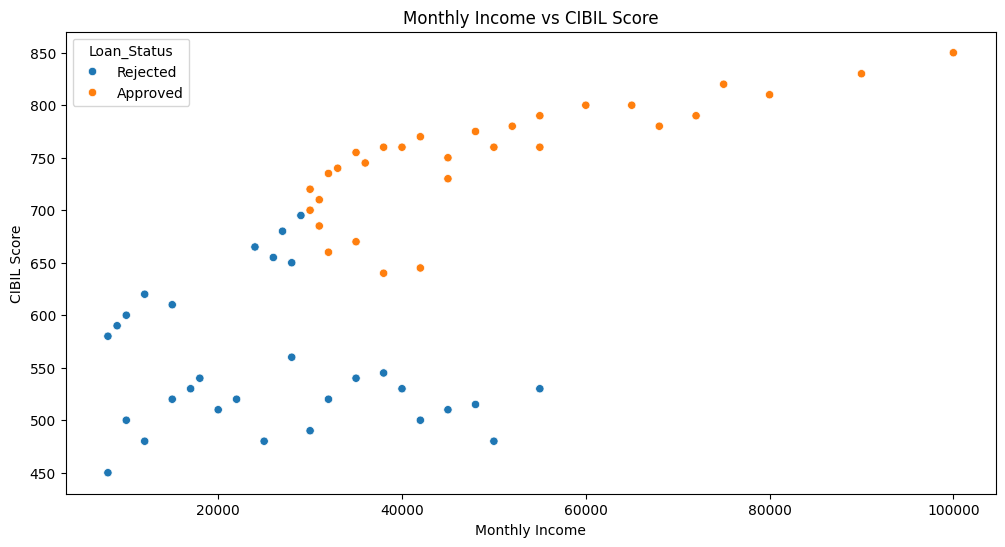

In [7]:
data.head(2)

# plot monthly_income, cibil_score

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.scatterplot(data=data, x='Monthly_Income', y='CIBIL_Score', hue='Loan_Status')
plt.title('Monthly Income vs CIBIL Score')
plt.xlabel('Monthly Income')
plt.ylabel('CIBIL Score')
plt.show()

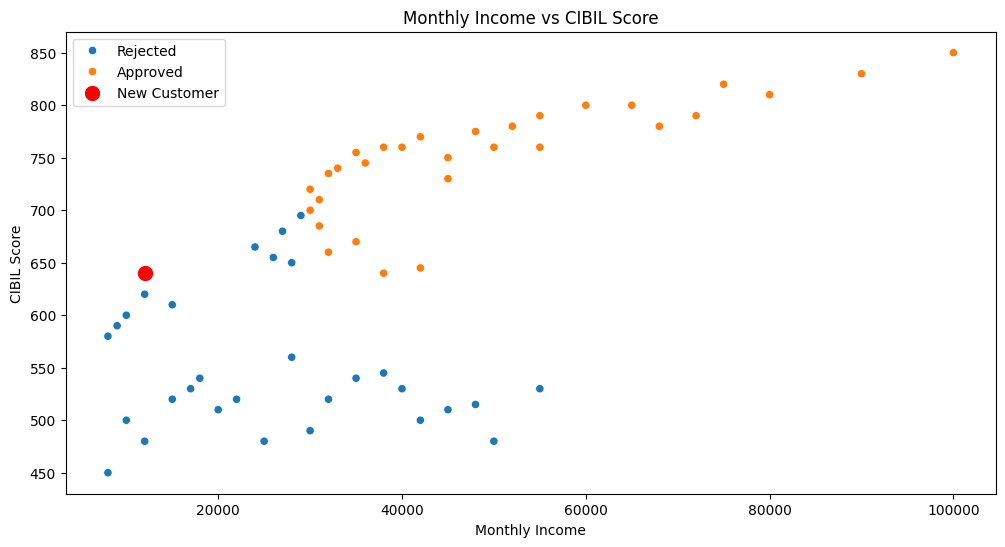

In [8]:
new_customer = [12000, 640]
# plot it
plt.figure(figsize=(12, 6))
sns.scatterplot(data=data, x='Monthly_Income', y='CIBIL_Score', hue='Loan_Status')
plt.scatter(x=new_customer[0], y=new_customer[1], color='red', s=100, label='New Customer')
plt.title('Monthly Income vs CIBIL Score')
plt.xlabel('Monthly Income')
plt.ylabel('CIBIL Score')
plt.legend()
plt.show()

In [9]:
import numpy as np

In [10]:
# Import the function
from utilities_function import create_knn_gif_clean

# Method 1: Auto-select a random rejected customer
gif_file = create_knn_gif_clean(data,new_cut=(40000, 780),output_file="knn_vibrant_good.gif")


Creating vibrant GIF...

  ✓ K=1: ✓ APPROVED
  ✓ K=3: ✓ APPROVED
  ✓ K=5: ✓ APPROVED
  ✓ K=7: ✓ APPROVED
  ✓ K=10: ✓ APPROVED
  ✓ K=15: ✓ APPROVED
  ✓ K=20: ✓ APPROVED

✅ Vibrant GIF saved: knn_vibrant_good.gif
   Color scheme: High contrast for better visibility


In [11]:
from supervised_vs_unsupervised import create_supervised_vs_unsupervised_comparison

# Same data, different questions!
img = create_supervised_vs_unsupervised_comparison(data)

✅ Comparison saved: supervised_vs_unsupervised.png

📊 UNSUPERVISED Learning Results:

Group 1: Risky:
  Count: 24 customers
  Avg Income: ₹35,292
  Avg CIBIL: 711
  (Actually: 19 Approved, 5 Rejected)

Group 2: Standard:
  Count: 11 customers
  Avg Income: ₹70,182
  Avg CIBIL: 801
  (Actually: 11 Approved, 0 Rejected)

Group 3: Premium:
  Count: 25 customers
  Avg Income: ₹25,760
  Avg CIBIL: 530
  (Actually: 0 Approved, 25 Rejected)
